**Theory**:        
The Quantum Fourier Transform (QFT) is the quantum analogue of the Discrete Fourier Transform. It maps a computational basis state |x⟩ into a superposition of states with relative phases encoding frequency information. For an n-qubit system, it applies Hadamard gates and controlled phase rotations R_k = CP(π/2^k), followed by bit-reversal swaps. QFT is a key subroutine in quantum phase estimation and Shor's factoring algorithm.                      

**Implementation**:                         
A 3-qubit QFT was implemented in Qiskit. The input state |101⟩ (decimal 5) was prepared using X gates on q0 and q2. The QFT circuit then applied a Hadamard gate to each qubit in sequence, with controlled phase rotations CP(π/2) and CP(π/4) encoding the phase relationships between qubits. A final SWAP gate on q0 and q2 corrected the bit ordering. The circuit was simulated using Qiskit's AerSimulator with 1024 shots.

        ┌───┐┌───┐                                         ░ ┌─┐      
   q_0: ┤ X ├┤ H ├─■────────■───────────────────────────X──░─┤M├──────
        └───┘└───┘ │P(π/2)  │       ┌───┐               │  ░ └╥┘┌─┐   
   q_1: ───────────■────────┼───────┤ H ├─■─────────────┼──░──╫─┤M├───
        ┌───┐               │P(π/4) └───┘ │P(π/2) ┌───┐ │  ░  ║ └╥┘┌─┐
   q_2: ┤ X ├───────────────■─────────────■───────┤ H ├─X──░──╫──╫─┤M├
        └───┘                                     └───┘    ░  ║  ║ └╥┘
meas: 3/══════════════════════════════════════════════════════╩══╩══╩═
                                                              0  1  2 
Measurement Results: {'001': 134, '101': 140, '011': 121, '111': 114, '010': 109, '000': 142, '110': 121, '100': 143}


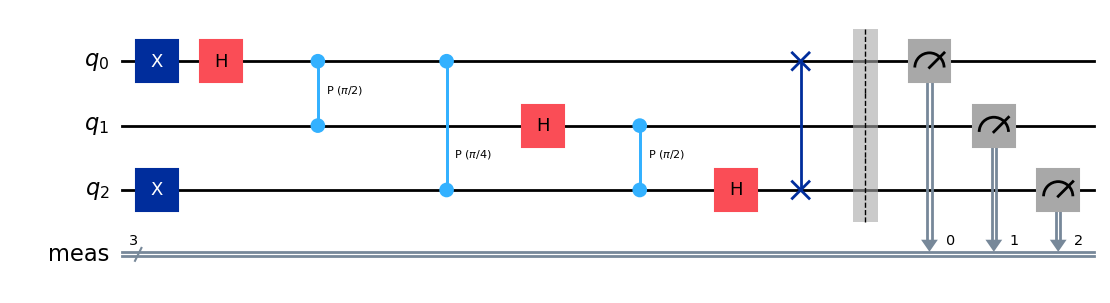

In [6]:
#Quantum Fourier Transform

!pip install qiskit qiskit-aer --quiet

#import libraries
from qiskit import QuantumCircuit,transpile
from qiskit_aer import AerSimulator
import numpy as np

#step 1 initialize state |101⟩ = 5
qc = QuantumCircuit(3)
qc.x(0)
qc.x(2)

# Step 2: Hadamard on q0
qc.h(0)

# Step 3: Controlled phase π/2 control q1, targetq0
qc.cp(np.pi/2,1,0)

# Step 4: Controlled phase π/4 control q2, target q0
qc.cp(np.pi/4,2,0)

#step 5 Hadamard to q1
qc.h(1)

# Step 6: Controlled phase π/2 control q2, target q1
qc.cp(np.pi/2,2,1)

#step 7 hadamard to q2
qc.h(2)

#step 8 swap gate between q0 and q2
qc.swap(0,2)

#measurement
qc.measure_all()
print(qc.draw())

#simulate
sim = AerSimulator()
transpiled = transpile(qc,sim)
result = sim.run(transpiled, shots=1024).result()

counts = result.get_counts()
print("Measurement Results:", counts)
qc.draw('mpl')



**Results**:                                      
The circuit was simulated using 1024 shots. Since the QFT produces a uniform superposition of all basis states for the input |101⟩, the measurement results showed approximately equal probability (~1/8 ≈ 12.5%) across all 8 computational basis states |000⟩ through |111⟩, confirming correct QFT behavior